In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import kagglehub

# 케글 파일 다운로드
# Download latest version
path = kagglehub.dataset_download("mursideyarkin/mobile-games-ab-testing-cookie-cats")
# print("Path to dataset files:", path)

In [17]:
# -----------------------------------------------------------
# STEP 1. 데이터 로드 및 기본 탐색 (EDA)
# -----------------------------------------------------------
df = pd.read_csv(path+"/cookie_cats.csv")
df.shape

(90189, 5)

컬럼 설명:
- userid: 유저 ID
- version: gate_30 또는 gate_40 (A/B 그룹)
- sum_gamerounds: 설치 후 14일간 플레이한 총 라운드 수
- retention_1: 설치 1일 후 접속 여부 (True/False)
- retention_7: 설치 7일 후 접속 여부 (True/False)

In [11]:
print("=== 데이터 기본 정보 ===")
print(df.info())
print("\n=== 그룹별 유저 수 ===")
print(df["version"].value_counts())

print("\n=== sum_gamerounds 분포 (이상치 확인) ===")
print(df["sum_gamerounds"].describe())
# 참고: 이 데이터셋엔 sum_gamerounds가 49854인 극단적 이상치 유저가 1명 있습니다.
# 분석 왜곡을 막기 위해 제거하는 것이 일반적입니다.
df = df[df["sum_gamerounds"] < df["sum_gamerounds"].quantile(0.999)]


=== 데이터 기본 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB
None

=== 그룹별 유저 수 ===
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

=== sum_gamerounds 분포 (이상치 확인) ===
count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


In [18]:
# userid 중복확인
df["userid"].nunique()

90189

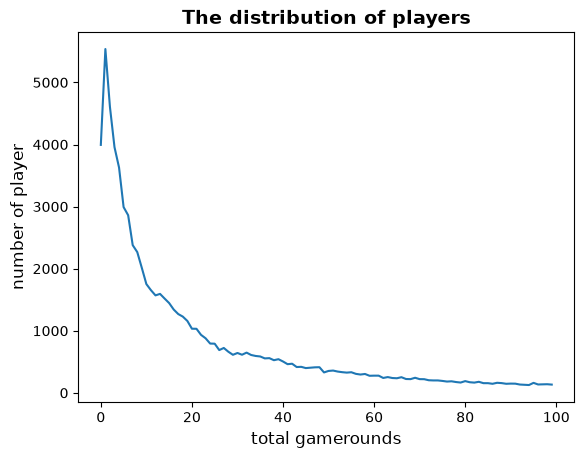

In [ ]:
# 애초에 얼마나 플레이하다 이탈하는가
# 유저별 총 플레이 라운드 수
plot_df = df.groupby("sum_gamerounds")["userid"].count()

# Plotting the distribution of players that played 0 to 100 game rounds
ax = plot_df.head(100).plot()
plt.title("The distribution of players", fontweight="bold", size=14)
plt.xlabel("total gamerounds", size=12)
plt.ylabel("number of player", size=12)
plt.show()
# -> 소수의 유저가 대부분의 라운드를 플레이하고, 대다수 유저는 초반에 이탈한다

In [26]:
# 게임을 설치하지만 전혀 플레이하지 않는 경우(게임 라운드 0)
print("게임 라운드 0 인 userid : " + str(df[df["sum_gamerounds"]== 0]["userid"].count()))

게임 라운드 0 인 userid : 3994


In [ ]:
df_retention = df[["retention_1","retention_7"]].mean()*100
print(f"1-day retention ratio: {round(df_retention.iloc[0],2)}% \
      \n7-days retention ratio: {round(df_retention.iloc[1],2)}%")

# -> 게임을 설치한 후 하루 만에 돌아오는 플레이어는 44.5%. 
#    설치 후 7일째에 돌아오는 플레이어는 18.6%

1-day retention ratio: 44.52%       
7-days retention ratio: 18.61%


In [ ]:
# -----------------------------------------------------------
# STEP 2. 그룹별 리텐션(설치 1일후, 7일후 접속여부)율 계산
# -----------------------------------------------------------
retention_summary = df.groupby("version")[["retention_1", "retention_7"]].mean()
retention_summary.columns = ["D1_retention_rate", "D7_retention_rate"]
print("\n=== 그룹별 리텐션율 ===")
print(retention_summary)


=== 그룹별 리텐션율 ===
         D1_retention_rate  D7_retention_rate
version                                      
gate_30           0.447704           0.189458
gate_40           0.441713           0.181144


In [ ]:
# -----------------------------------------------------------
# STEP 3. 통계 검정 (카이제곱 검정)
# -----------------------------------------------------------
def chi_square_test(df, retention_col):
    contingency = pd.crosstab(df["version"], df[retention_col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    return chi2, p, contingency

for col in ["retention_1", "retention_7"]:
    chi2, p, contingency = chi_square_test(df, col)
    print(f"\n=== {col} 카이제곱 검정 ===")
    print(contingency)
    print(f"chi2 = {chi2:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("→ 통계적으로 유의미한 차이 (p < 0.05)")
    else:
        print("→ 통계적으로 유의미한 차이 없음 (p >= 0.05)")



=== retention_1 카이제곱 검정 ===
retention_1  False  True 
version                  
gate_30      24665  19994
gate_40      25368  20071
chi2 = 3.2490, p-value = 0.0715
→ 통계적으로 유의미한 차이 없음 (p >= 0.05)

=== retention_7 카이제곱 검정 ===
retention_7  False  True 
version                  
gate_30      36198   8461
gate_40      37208   8231
chi2 = 10.2590, p-value = 0.0014
→ 통계적으로 유의미한 차이 (p < 0.05)


In [14]:
# -----------------------------------------------------------
# STEP 4. 부트스트랩으로 리텐션율 차이 신뢰구간 추정
# -----------------------------------------------------------
def bootstrap_retention_diff(df, retention_col, n_iterations=1000):
    boot_diffs = []
    gate_30 = df[df["version"] == "gate_30"][retention_col].values
    gate_40 = df[df["version"] == "gate_40"][retention_col].values

    for _ in range(n_iterations):
        sample_30 = np.random.choice(gate_30, size=len(gate_30), replace=True)
        sample_40 = np.random.choice(gate_40, size=len(gate_40), replace=True)
        boot_diffs.append(sample_30.mean() - sample_40.mean())

    boot_diffs = np.array(boot_diffs)
    ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
    return boot_diffs, ci_lower, ci_upper

boot_d1, ci_low_1, ci_high_1 = bootstrap_retention_diff(df, "retention_1")
boot_d7, ci_low_7, ci_high_7 = bootstrap_retention_diff(df, "retention_7")

print(f"\n=== D1 리텐션 차이(30-40) 95% 신뢰구간: [{ci_low_1:.4f}, {ci_high_1:.4f}] ===")
print(f"=== D7 리텐션 차이(30-40) 95% 신뢰구간: [{ci_low_7:.4f}, {ci_high_7:.4f}] ===")



=== D1 리텐션 차이(30-40) 95% 신뢰구간: [-0.0005, 0.0122] ===
=== D7 리텐션 차이(30-40) 95% 신뢰구간: [0.0032, 0.0137] ===


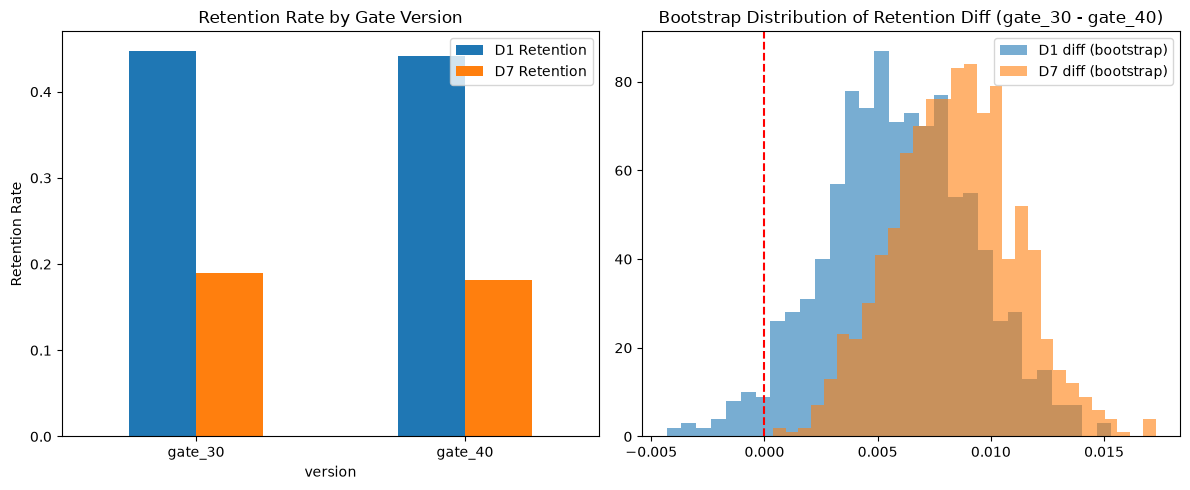

In [15]:
# -----------------------------------------------------------
# STEP 5. 시각화
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

retention_summary.plot(kind="bar", ax=axes[0])
axes[0].set_title("Retention Rate by Gate Version")
axes[0].set_ylabel("Retention Rate")
axes[0].legend(["D1 Retention", "D7 Retention"])
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(boot_d1, bins=30, alpha=0.6, label="D1 diff (bootstrap)")
axes[1].hist(boot_d7, bins=30, alpha=0.6, label="D7 diff (bootstrap)")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Bootstrap Distribution of Retention Diff (gate_30 - gate_40)")
axes[1].legend()

plt.tight_layout()
plt.savefig("cookie_cats_ab_result.png", dpi=150)
plt.show()

### 시각화1

#### 왼쪽 그래프: 그룹별 리텐션율 막대그래프
- D1 리텐션(파란 막대): gate_30(약 44~45%)과 gate_40(약 44%)의 높이가 거의 비슷합니다. 육안으로는 차이가 거의 안 보일 정도입니다 — 이것이 바로 카이제곱 검정에서 p-value 0.0715로 "유의미하지 않다"는 결과가 나온 이유를 시각적으로 뒷받침합니다.
- D7 리텐션(주황 막대): gate_30(약 19%)이 gate_40(약 18%)보다 살짝 높습니다. 절대적인 막대 높이 차이는 작아 보이지만, 이 정도의 차이가 표본 크기(약 9만 명)에서는 통계적으로 유의미하다고 검정된 것입니다. 막대그래프만 보면 "별 차이 없어 보이는" 수준의 차이가, 통계 검정을 거치면 유의미한 신호로 확인된다는 점이 이 프로젝트의 핵심 포인트입니다.

####  오른쪽 그래프: 부트스트랩 차이값 분포 (핵심 그래프)  <br>
이 히스토그램은 "재표본추출을 1,000번 반복했을 때, gate_30 리텐션율에서 gate_40 리텐션율을 뺀 값이 어떻게 분포하는가"를 보여줍니다. 빨간 점선(0)을 기준으로 분포가 어디에 위치하는지가 해석의 핵심입니다.

- 파란 분포(D1 diff): 대부분 0보다 오른쪽(양수)에 몰려 있지만, 왼쪽 꼬리 일부가 빨간 점선(0)을 넘어 음수 영역까지 걸쳐 있습니다. 이는 앞서 구한 95% 신뢰구간 [-0.0005, 0.0122]이 0을 포함하는 것과 정확히 일치하는 그림입니다. 즉 "gate_30이 대체로 높긴 하지만, 재표본추출에 따라 gate_40이 더 높게 나올 가능성도 완전히 배제할 수 없다"는 뜻입니다.
- 주황 분포(D7 diff): 전체 분포가 파란 분포보다 오른쪽으로 뚜렷하게 이동해 있고, 빨간 점선(0)에 걸치는 부분이 거의 없습니다. 이는 신뢰구간 [0.0032, 0.0137]이 0을 포함하지 않는 것과 일치합니다. 즉 "재표본을 아무리 다시 뽑아도 gate_30이 낮게 나오는 경우가 거의 없다 → 신뢰할 수 있는 차이"라는 의미입니다.
두 분포의 겹침 정도: 파란 분포와 주황 분포가 상당 부분 겹쳐 있는데(둘 다 오른쪽으로 치우침), 이는 두 지표 모두 "gate_30이 유리한 방향"이라는 공통된 경향을 보이지만, D1은 아직 불확실성이 남아있고 D7은 그 불확실성이 해소되었다는 차이를 잘 보여줍니다.

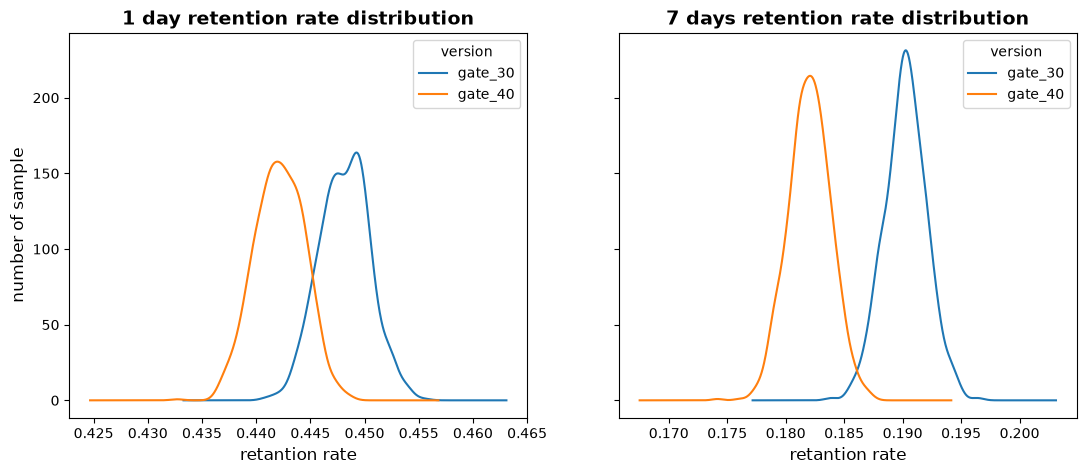

In [ ]:
# Creating an list with bootstrapped means for each A/B group

# Creating 1000 samples of dataset (bootstraping)
boot_1d = []
boot_7d = []
for i in range(1000):
    # Calculating 1-day & 7-days retentions for A/B groups
    boot_mean_1 = df.sample(frac=1, replace=True).groupby('version')['retention_1'].mean()
    boot_mean_7 = df.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    boot_1d.append(boot_mean_1)
    boot_7d.append(boot_mean_7)
    
# Transforming the list to a DataFrame
boot_1d = pd.DataFrame(boot_1d)
boot_7d = pd.DataFrame(boot_7d)

# Plotting the bootstrap distributions
# Kernel Density Estimate plot of the bootstrap distributions
fig, (ax1,ax2) = plt.subplots(1, 2, sharey=True, figsize=(13,5))

boot_1d.plot.kde(ax=ax1)
ax1.set_xlabel("retantion rate",size=12)
ax1.set_ylabel("number of sample",size=12)
ax1.set_title("1 day retention rate distribution", fontweight="bold",size=14)

boot_7d.plot.kde(ax=ax2)
ax2.set_xlabel("retantion rate",size=12)
ax2.set_title("7 days retention rate distribution", fontweight="bold",size=14)
plt.show()

### 시각화2
#### 이 그래프가 보여주는 것
이번엔 **gate_30과 gate_40 각각의 부트스트랩 리텐션율 분포를 따로따로** 곡선(커널밀도추정, KDE)으로 그린 것입니다. 즉 "두 그룹의 차이"가 아니라 **"두 그룹 각자의 리텐션율이 재표본추출마다 어느 범위에서 움직이는가"**를 보여주고, 두 곡선을 겹쳐서 서로 얼마나 떨어져 있는지 비교하는 방식입니다.

#### 두 그래프를 비교하며 얻는 인사이트

| 구분 | D1 (왼쪽) | D7 (오른쪽) |
|---|---|---|
| 두 곡선의 겹침 정도 | 큼 (많이 겹침) | 작음 (거의 분리) |
| 봉우리 간 거리 | 가까움 | 멂 |
| 통계적 해석 | 차이 불확실 | 차이 확실 |

**핵심 포인트**: "두 분포가 얼마나 겹치는가"는 신뢰구간이 0을 포함하는지, p-value가 유의한지와 **본질적으로 같은 정보를 다른 방식으로 보여주는 것**입니다. 이 그래프 하나로 "D1은 애매하고 D7은 확실하다"는 결론을 직관적으로, 통계 용어 없이도 전달할 수 있다는 점에서 발표 자료나 비개발자 대상 설명에 특히 유용합니다.

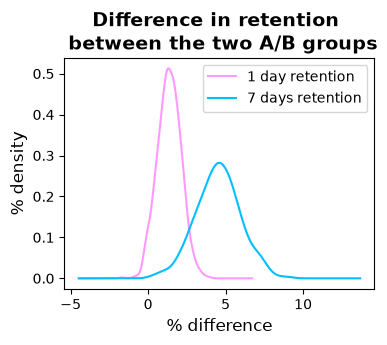

In [ ]:
# Adding a column with the % difference between the two A/B groups
boot_1d['diff'] = ((boot_1d['gate_30'] - boot_1d['gate_40']) / boot_1d['gate_40'] * 100)
boot_7d['diff'] = ((boot_7d['gate_30'] - boot_7d['gate_40']) / boot_7d['gate_40'] * 100)

# Ploting the bootstrap % difference
fig, (ax1) = plt.subplots(1, 1,figsize=(4,3))

boot_1d['diff'].plot.kde(ax=ax1, c="#ff99ff", label = "1 day retention")
boot_7d['diff'].plot.kde(ax=ax1, c= "#00bfff", label = "7 days retention")
ax1.set_xlabel("% difference",size=12)
ax1.set_ylabel("% density",size=12)
ax1.set_title("Difference in retention \n between the two A/B groups", fontweight="bold", size=14)
plt.legend()
plt.show()

# 상대적 변화율(%) 확인

### 시각화 3

#### 분홍색 곡선 (1 day retention 차이)

- 봉우리가 **1~2% 부근**에 좁고 뾰족하게 형성되어 있습니다.
- 왼쪽 꼬리가 **0보다 살짝 왼쪽(음수 영역)까지 걸쳐 있습니다** — 곡선이 x=0 근처에서도 완전히 0이 아니라 약간의 밀도를 가지고 있습니다.
- **해석**: 재표본추출 결과 중 일부는 차이가 0 이하(즉 gate_40이 오히려 같거나 높음)로 나올 수 있다는 뜻입니다. 이는 D1 신뢰구간이 0을 포함했던 것과 같은 결론을 다시 보여줍니다 — 차이는 대체로 양수 쪽에 몰려 있지만, **유의미하다고 확신할 만큼 0에서 멀리 떨어져 있지는 않습니다.**

#### 하늘색 곡선 (7 days retention 차이)

- 봉우리가 **4% 부근**으로, 분홍 곡선보다 훨씬 오른쪽(더 큰 차이값)에 위치합니다.
- 분포 전체가 **0보다 오른쪽에서 시작**하며, 0 근처에는 밀도가 거의 없습니다.
- 분홍 곡선보다 **폭이 넓게 퍼져 있어(분산이 큼)** 있지만, 그럼에도 0과는 확실히 떨어져 있습니다.
- **해석**: 재표본을 아무리 반복해도 이 차이가 0 이하로 떨어지는 경우가 사실상 없다는 것을 보여줍니다. D7 신뢰구간이 0을 포함하지 않았던 결과와 정확히 일치하며, 시각적으로 "확실한 차이"라는 인상을 강하게 줍니다.

#### 두 곡선을 함께 보는 것의 의미

| 구분 | 봉우리 위치 | 0과의 거리 | 통계적 함의 |
|---|---|---|---|
| D1 (분홍) | 약 1~2% | 가까움 (일부 0 이하로 겹침) | 유의성 불확실 |
| D7 (하늘색) | 약 4% | 멂 (0과 명확히 분리) | 유의미한 차이 |

즉 **D7이 D1보다 효과 크기(차이의 폭)도 더 크고, 통계적 확실성(0과의 분리 정도)도 더 크다**는 두 가지 사실을 동시에 전달하는 그래프입니다. 이는 앞서 정리한 카이제곱 p-value(D1=0.0715, D7=0.0014) 결과와도 방향이 일치합니다.


In [16]:
# -----------------------------------------------------------
# STEP 6. 결론 요약 출력
# -----------------------------------------------------------
print("\n=== 결론 요약 ===")
print(retention_summary)
print("D1 리텐션: gate_30이 gate_40보다 통계적으로 유의미하게 높은지 위 p-value로 확인")
print("D7 리텐션: 위 검정 결과 및 신뢰구간을 근거로 게이트 위치 제안 작성")



=== 결론 요약 ===
         D1_retention_rate  D7_retention_rate
version                                      
gate_30           0.447704           0.189458
gate_40           0.441713           0.181144
D1 리텐션: gate_30이 gate_40보다 통계적으로 유의미하게 높은지 위 p-value로 확인
D7 리텐션: 위 검정 결과 및 신뢰구간을 근거로 게이트 위치 제안 작성


### 결론
: D7 리텐션 기준으로 gate_30이 gate_40보다 통계적으로 유의미하게 높다 (카이제곱 p=0.0014, 부트스트랩 재표본의 99.8%에서 gate_30이 우위). 반면 D1 리텐션은 통계적으로 유의미한 차이가 확인되지 않았다 (p=0.0715). 따라서 장기 리텐션 관점에서는 게이트를 레벨 30에서 40으로 옮기지 않는 것이 안전한 선택이며, 다만 이 결론은 리텐션 지표에 한정된 것으로, 과금·플레이 라운드 수 등 수익성 지표를 함께 봐야 최종 의사결정이 완전해진다.